# STATISTICAL LEARNING FINAL PROJECT
# Beta Distribution
## Raissa Kitenge

In [31]:
import pandas as pd
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [32]:
#  Load feature-engineered data

df = pd.read_csv("/content/drive/MyDrive/feature_engineered_real_estate.csv")
df.head()

,TotalFinishedArea,LivingUnits,TotalAppraisedValue,SaleYear,SaleMonth,PriceRatio,AssrLandUse_APT FOUR,AssrLandUse_CONDOMINIMUM,AssrLandUse_MULTI DWLG,AssrLandUse_ONE FAMILY,AssrLandUse_THREE FAMILY,AssrLandUse_TWO FAMILY
0,1092.0,1.0,187200,2024,7,1.383547,False,False,False,True,False,False
1,936.0,1.0,192300,2022,4,1.081643,False,False,False,True,False,False
2,1111.0,1.0,148400,2023,12,0.842318,False,False,False,True,False,False
3,1684.0,1.0,197900,2021,1,0.894391,False,False,False,True,False,False
4,900.0,1.0,170700,2021,9,1.101347,False,False,False,True,False,False


In [33]:
# Select predictors

predictor_cols = [
    "TotalFinishedArea",
    "LivingUnits",
    "SaleYear",
    "SaleMonth",
    "AssrLandUse_APT FOUR",
    "AssrLandUse_CONDOMINIUM",
    "AssrLandUse_MULTI DWLG",
    "AssrLandUse_ONE FAMILY",
    "AssrLandUse_THREE FAMILY",
    "AssrLandUse_TWO FAMILY"
]
# Keep only columns that actually exist
predictor_cols = [col for col in predictor_cols if col in df.columns]

X = df[predictor_cols].copy()
y = df["PriceRatio"].copy()

print("Predictors used:")
print(X.columns.tolist())
print("\nShape:", X.shape)


Predictors used:
['TotalFinishedArea', 'LivingUnits', 'SaleYear', 'SaleMonth', 'AssrLandUse_APT FOUR', 'AssrLandUse_MULTI DWLG', 'AssrLandUse_ONE FAMILY', 'AssrLandUse_THREE FAMILY', 'AssrLandUse_TWO FAMILY']

Shape: (3137, 9)


In [34]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [35]:
# Standardize only continuous predictors

cont_cols = [col for col in ["TotalFinishedArea", "LivingUnits", "SaleYear", "SaleMonth"] if col in X_train.columns]
bin_cols = [col for col in X_train.columns if col not in cont_cols]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cont_cols] = scaler.fit_transform(X_train[cont_cols])
X_test_scaled[cont_cols] = scaler.transform(X_test[cont_cols])

In [36]:
# Rescale PriceRatio from (0.5, 1.5) to (0, 1)
# Beta likelihood requires values strictly inside (0, 1)

def rescale_to_unit_interval(y, lower=0.5, upper=1.5, eps=1e-4):
    y_scaled = (y - lower) / (upper - lower)
    y_scaled = np.clip(y_scaled, eps, 1 - eps)
    return y_scaled

y_train_beta = rescale_to_unit_interval(y_train)
y_test_beta = rescale_to_unit_interval(y_test)

print("\nRescaled target summary:")
print(pd.Series(y_train_beta).describe())


Rescaled target summary:
count    2509.000000
mean        0.588088
std         0.221520
min         0.000835
25%         0.460591
50%         0.588348
75%         0.754376
max         0.999900
Name: PriceRatio, dtype: float64


In [37]:
# Convert to numpy arrays

# Convert all predictors to float
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled = X_test_scaled.astype(float)

X_train_np = X_train_scaled.to_numpy(dtype=float)
X_test_np = X_test_scaled.to_numpy(dtype=float)

y_train_np = np.asarray(y_train_beta, dtype=float)
y_test_np = np.asarray(y_test_beta, dtype=float)

print(X_train_np.dtype)
print(y_train_np.dtype)
print(X_train_np.shape, y_train_np.shape)

float64
float64
(2509, 9) (2509,)


In [38]:
print(X_train_scaled.dtypes)
print(X_train_scaled.head())
print(type(X_train_np))
print(X_train_np.dtype)

TotalFinishedArea           float64
LivingUnits                 float64
SaleYear                    float64
SaleMonth                   float64
AssrLandUse_APT FOUR        float64
AssrLandUse_MULTI DWLG      float64
AssrLandUse_ONE FAMILY      float64
AssrLandUse_THREE FAMILY    float64
AssrLandUse_TWO FAMILY      float64
dtype: object
      TotalFinishedArea  LivingUnits  SaleYear  SaleMonth  \
1746           0.112903     0.043157 -0.022384  -0.464576   
3002          -0.169900    -0.185284  1.732629  -0.176697   
1055          -0.138561    -0.185284 -1.777396   0.974819   
221           -0.219710    -0.185284 -0.022384  -0.464576   
543           -0.128893     0.043157  0.855123  -0.176697   

      AssrLandUse_APT FOUR  AssrLandUse_MULTI DWLG  AssrLandUse_ONE FAMILY  \
1746                   0.0                     0.0                     0.0   
3002                   0.0                     0.0                     1.0   
1055                   0.0                     0.0           

In [39]:
# Beta Bayesian Regression

with pm.Model() as beta_model:

    # Data containers
    X_data = pm.Data("x_data", X_train_np)
    y_data = pm.Data("y_data", y_train_np)

    # Priors
    intercept = pm.Normal("Intercept", mu=0, sigma=2)
    beta = pm.Normal("beta", mu=0, sigma=1, shape=n_features)

    # Precision / concentration parameter
    phi = pm.Gamma("phi", alpha=2, beta=0.1)

    # Linear predictor
    eta = intercept + pm.math.dot(X_data, beta)

    # Mean on (0,1)
    mu = pm.Deterministic("mu", pm.math.sigmoid(eta))

    # Beta parameters
    alpha_param = mu * phi
    beta_param = (1 - mu) * phi

    # Likelihood
    y_like = pm.Beta("y_like", alpha=alpha_param, beta=beta_param, observed=y_data)

    # Sampling
    trace_beta = pm.sample(
        1000,
        tune=1000,
        chains=2,
        target_accept=0.90,
        return_inferencedata=True,
        random_seed=42
    )

Output()

In [40]:
# Posterior summary

summary_beta = az.summary(trace_beta, var_names=["Intercept", "beta", "phi"],round_to=4)
print(summary_beta)

             mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
Intercept  0.4711  0.0424  0.3894   0.5484     0.0016   0.0010   690.6731   
beta[0]   -0.4107  0.1303 -0.6615  -0.1734     0.0045   0.0031   847.1756   
beta[1]    0.4165  0.1324  0.1622   0.6589     0.0045   0.0032   849.2001   
beta[2]    0.3824  0.0190  0.3489   0.4199     0.0005   0.0005  1751.9196   
beta[3]    0.0971  0.0184  0.0623   0.1297     0.0004   0.0004  1737.6914   
beta[4]    0.1693  0.1974 -0.2065   0.5251     0.0043   0.0041  2125.0193   
beta[5]   -0.2732  0.5022 -1.2208   0.6127     0.0104   0.0136  2360.9414   
beta[6]   -0.1292  0.0526 -0.2261  -0.0262     0.0020   0.0012   718.2094   
beta[7]   -0.0883  0.0571 -0.1969   0.0162     0.0019   0.0012   934.4564   
beta[8]   -0.2633  0.0591 -0.3806  -0.1584     0.0020   0.0011   882.2822   
phi        4.1111  0.1035  3.9172   4.2982     0.0024   0.0022  1791.4563   

            ess_tail   r_hat  
Intercept  1129.9682  1.0009  
beta[0]    10

In [41]:
# Rename beta rows to match feature names

beta_rows = coef_summary.loc[coef_summary.index.str.startswith("beta[")].copy()
beta_rows["Feature"] = feature_names
beta_rows = beta_rows[["Feature", "mean", "sd", "hdi_3%", "hdi_97%", "r_hat"]]

print("\nFeature-level posterior summary:")
print(beta_rows)


Feature-level posterior summary:
                          Feature    mean      sd  hdi_3%  hdi_97%   r_hat
beta[0]         TotalFinishedArea -0.4107  0.1303 -0.6615  -0.1734  1.0027
beta[1]               LivingUnits  0.4165  0.1324  0.1622   0.6589  1.0026
beta[2]                  SaleYear  0.3824  0.0190  0.3489   0.4199  1.0024
beta[3]                 SaleMonth  0.0971  0.0184  0.0623   0.1297  1.0004
beta[4]      AssrLandUse_APT FOUR  0.1693  0.1974 -0.2065   0.5251  1.0004
beta[5]    AssrLandUse_MULTI DWLG -0.2732  0.5022 -1.2208   0.6127  1.0012
beta[6]    AssrLandUse_ONE FAMILY -0.1292  0.0526 -0.2261  -0.0262  1.0018
beta[7]  AssrLandUse_THREE FAMILY -0.0883  0.0571 -0.1969   0.0162  1.0023
beta[8]    AssrLandUse_TWO FAMILY -0.2633  0.0591 -0.3806  -0.1584  1.0007


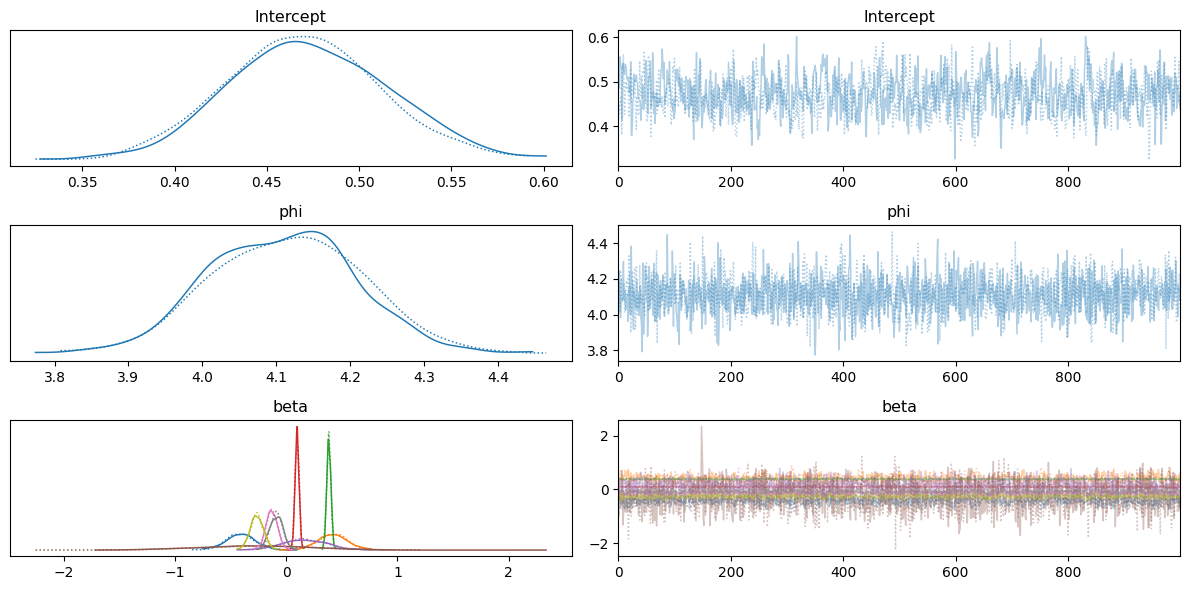

In [42]:
# Trace plots

az.plot_trace(trace_beta, var_names=["Intercept", "phi", "beta"])
plt.tight_layout()
plt.show()


In [43]:
# Posterior prediction on test set

intercept_mean = coef_summary.loc["Intercept", "mean"]
phi_mean = coef_summary.loc["phi", "mean"]

beta_means = np.array([
    coef_summary.loc[f"beta[{i}]", "mean"] for i in range(n_features)
])

eta_test = intercept_mean + X_test_np @ beta_means
mu_test = 1 / (1 + np.exp(-eta_test))

# Convert predictions back to original PriceRatio scale
y_pred_ratio = 0.5 + mu_test * (1.5 - 0.5)

In [44]:
# RMSE on original PriceRatio scale

rmse_beta = np.sqrt(np.mean((y_test.values - y_pred_ratio) ** 2))
print("\nBeta Bayesian Test RMSE:", round(rmse_beta, 4))


Beta Bayesian Test RMSE: 0.21


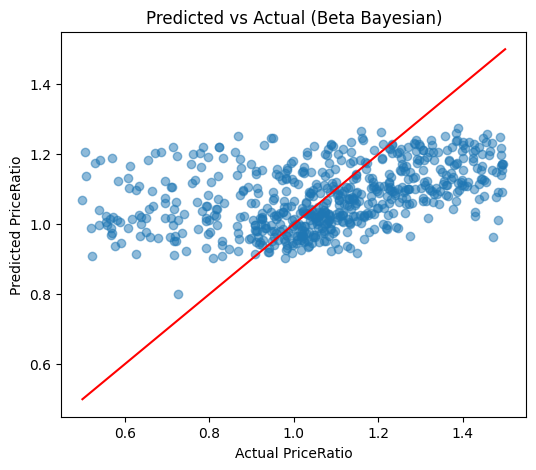

In [45]:
# Predicted vs actual plot

plt.figure(figsize=(6, 5))
plt.scatter(y_test.values, y_pred_ratio, alpha=0.5)
plt.plot([0.5, 1.5], [0.5, 1.5], color="red")
plt.xlabel("Actual PriceRatio")
plt.ylabel("Predicted PriceRatio")
plt.title("Predicted vs Actual (Beta Bayesian)")
plt.show()

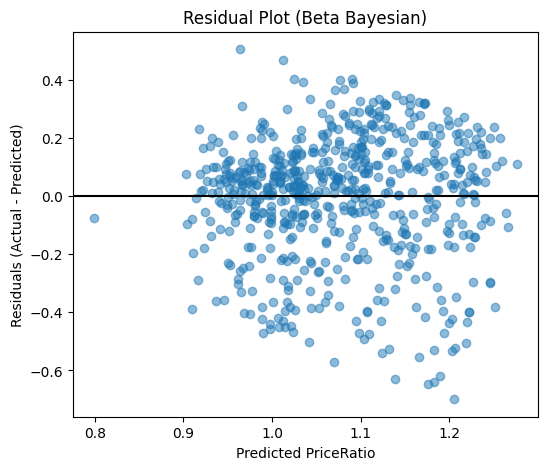

In [46]:
# Residual plot

residuals_beta = y_test.values - y_pred_ratio

plt.figure(figsize=(6, 5))
plt.scatter(y_pred_ratio, residuals_beta, alpha=0.5)
plt.axhline(0, color="black")
plt.xlabel("Predicted PriceRatio")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot (Beta Bayesian)")
plt.show()

In [47]:
print(y_train_np.min(), y_train_np.max())

0.0008347245409014992 0.9999


In [48]:
!jupyter nbconvert --to pdf '/content/drive/MyDrive/Colab Notebooks/Beta Distribution.ipynb'

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Beta Distribution.ipynb to pdf
[NbConvertApp] Writing 46839 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 49191 bytes to /content/drive/MyDrive/Colab Notebooks/Beta Distribution.pdf
